<a href="https://colab.research.google.com/github/Teivak/FaceRecognitionProject/blob/main/4_HW_RecognitionPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
project_path = 'PROJECT/FaceAlignment'

# **1. Детекция**

In [ ]:
!pip install insightface onnxruntime-gpu
!pip install opencv-python


  Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl (40.2 MB)


ERROR: Could not install packages due to an OSError: [WinError 5] Отказано в доступе: 'C:\\Users\\dukei\\anaconda3\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
model ignore: C:\Users\dukei/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecu

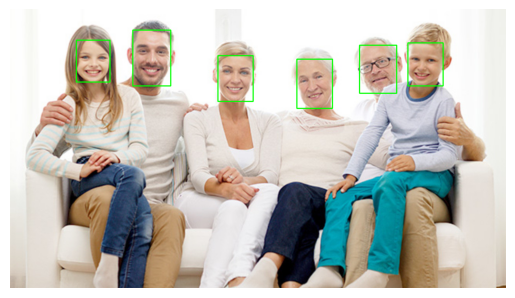

In [ ]:
from insightface.app import FaceAnalysis
import cv2
import matplotlib.pyplot as plt

# 'det_name' позволяет выбрать конкретную модель SCRFD (например, 'scrfd_10g_bnkps')
detection_model = FaceAnalysis(allowed_modules=['detection'], det_name='scrfd_10g_bnkps')
detection_model.prepare(ctx_id=0, det_size=(640, 640)) # ctx_id=0 для GPU

# Загрузка фото
img_dir = f'{project_path}/family.jpg'
input_img = cv2.imread(img_dir)

# Детекция лиц
faces = detection_model.get(input_img)

# Создаем копию изображения для рисования
output_img_scrfd = input_img.copy()

# Визуализация предсказанных ббоксов
for face in faces:
    # Координаты ббокса
    bbox = face.bbox.astype(int)
    # Рисуем прямоугольник
    cv2.rectangle(output_img_scrfd, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2) # Зеленый цвет, толщина 2

# Отображаем изображение с ограничивающими рамками с помощью matplotlib
plt.imshow(cv2.cvtColor(output_img_scrfd, cv2.COLOR_BGR2RGB))
plt.axis('off') # Отключаем оси
plt.show()

# **2. Предсказание лэндмарков**

In [ ]:
# %load PROJECT/FaceAlignment/hourglass_network.py

from torch import nn

# Residual просто перенёс из блока выше
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)


class HourglassModule(nn.Module):
    def __init__(self, depth, in_channels, out_channels):
        super().__init__()
        self.depth = depth # Глубина текущего Hourglass модуля (количество рекурсивных вложений)
        self.in_channels = in_channels
        self.out_channels = out_channels

        # 1. Начальный ResidualBlock:
        # Принимает входные признаки и преобразует их. Его выход будет использован для skip-connection
        self.res1 = ResidualBlock(in_channels, out_channels)

        # 2. Слой Downsampling:
        # Уменьшает пространственное разрешение признаков в 2 раза
        self.downsample = nn.MaxPool2d(kernel_size=2)

        # 3. ResidualBlock после Downsampling:
        # Обрабатывает признаки после уменьшения разрешения.
        self.res2 = ResidualBlock(out_channels, out_channels)

        # 4. Рекурсивная часть:
        # Если глубина > 1, то запускается ещё следующий (вложенный) HourglassModule
        # Если глубина = 1, то используется обычный ResidualBlock на дне архитектуры.
        if depth > 1:
            self.recursive_hg = HourglassModule(depth - 1, out_channels, out_channels)
        else:
            self.bottom_res = ResidualBlock(out_channels, out_channels)

        # 5. Слой Upsampling:
        # Увеличивает пространственное разрешение признаков обратно в 2 раза, восстанавливая их размер.
        # Используется mode='nearest' для простого увеличения (без обучения параметров).
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

        # 6. Финальный ResidualBlock:
        # Обрабатывает объединенные признаки после upsampling и skip-connection.
        self.res3 = ResidualBlock(out_channels, out_channels)

    def forward(self, x):
        # 1. Проход через первый ResidualBlock:
        # `skip_connection` сохраняет признаки до downsampling, чтобы позже объединить их с upsampled-признаками
        skip_connection = self.res1(x)

        # 2. Downsample:
        # Уменьшаем пространственное разрешение признаков
        down = self.downsample(skip_connection)

        # 3. Проход через второй ResidualBlock:
        # Обрабатываем признаки после downsample
        down_res = self.res2(down)

        # 4. Рекурсивный вызов или базовый ResidualBlock:
        # Если `depth > 1`, вызываем вложенный HourglassModule
        # Если `depth = 1`, это самый глубокий уровень, и мы просто используем `bottom_res`
        if self.depth > 1:
            bottom_out = self.recursive_hg(down_res)
        else:
            bottom_out = self.bottom_res(down_res)

        # 5. Upsample:
        # Увеличиваем пространственное разрешение признаков обратно
        up = self.upsample(bottom_out)

        # 6. Объединение признаков:
        # Реализация skip_connection
        combined_features = up + skip_connection

        # 7. Финальный ResidualBlock:
        # Последняя обработка объединенных признаков перед выходом из текущего Hourglass модуля
        output = self.res3(combined_features)

        return output


class HourglassHead(nn.Module):
    def __init__(self, in_channels, num_landmarks):
        super().__init__()
        # Преобразует вывод в нужное кол-во каналов, дальше BatchNorm и ReLu (по рекомендации выше)
        self.conv = nn.Conv2d(in_channels, num_landmarks, kernel_size=1)
        self.bn = nn.BatchNorm2d(num_landmarks)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


class StackedHourglassNetwork(nn.Module):
    def __init__(self, num_stacks, depth, in_channels, out_channels, num_landmarks):
        super().__init__()
        self.num_stacks = num_stacks
        self.num_landmarks = num_landmarks

        # Входные данные: (3, 128, 128)
        # Подготовка данных для Hourglass модулей
        self.preprocess = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1), # (64, 128, 128)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResidualBlock(64, 128), # (128, 128, 128)
            nn.MaxPool2d(kernel_size=2), # (128, 64, 64)
            ResidualBlock(128, in_channels) # (in_channels, 64, 64)
        )
        # Выход preprocess: (in_channels, 64, 64)

        self.hourglass_modules = nn.ModuleList([
            HourglassModule(depth, in_channels, out_channels) for _ in range(num_stacks)
        ])

        self.heads = nn.ModuleList([
            HourglassHead(out_channels, num_landmarks) for _ in range(num_stacks)
        ])

        # Промежуточные слои для intermediate supervision
        self.intermediate_convs_features = nn.ModuleList()
        self.intermediate_convs_heatmaps = nn.ModuleList()

        for i in range(num_stacks - 1):
            self.intermediate_convs_features.append(nn.Conv2d(out_channels, in_channels, kernel_size=1))
            self.intermediate_convs_heatmaps.append(nn.Conv2d(num_landmarks, in_channels, kernel_size=1))

    def forward(self, x):
        # Начальная обработка
        # x_in: (3, 128, 128)
        x = self.preprocess(x) # x: (in_channels, 64, 64)

        outputs = []
        for i in range(self.num_stacks):
            # HourglassModule
            hg_out = self.hourglass_modules[i](x)

            # HourglassHead
            heatmap_out = self.heads[i](hg_out)
            outputs.append(heatmap_out)

            # Для промежуточных стеков
            if i < self.num_stacks - 1:
                # Преобразование карты признаков в признаки
                heatmap_to_features = self.intermediate_convs_heatmaps[i](heatmap_out)
                # Преобразование выхода HG в признаки
                hg_out_to_features = self.intermediate_convs_features[i](hg_out)
                # Суммирование признаков
                x = x + hg_out_to_features + heatmap_to_features

        return outputs # Список карт признаков


In [ ]:
# %load PROJECT/FaceAlignment/FaceRecognitionDataset.py

import numpy as np
import os
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T
from torchvision.tv_tensors import KeyPoints
import cv2 # Импортируем cv2 для функции face_align
from PROJECT.FaceAlignment.face_align import face_align # Добавляем явный импорт face_align
from sklearn.preprocessing import LabelEncoder # Импортируем LabelEncoder

# Мы сохраняем этот блок кода отдельно, так что желательно,
# чтобы все нужные библиотеки, а также path были доступны
path = '/home/timof/.cache/kagglehub/datasets/kevinpatel04/celeba-original-wild-images/versions/1' # This 'path' is passed as images_path to the dataset
aligned_images_dir = 'PROJECT/FaceAlignment/aligned_images'

def create_heatmap(size, landmark, sigma=2):
    """
    Создаёт один heatmap с гауссовым ядром вокруг точки.

    :param size: (height, width) — размер heatmap'а
    :param landmark:(x, y) — координаты точки
    :param sigma
    :return: heatmap массив
    """
    x, y = landmark
    h, w = size

    # Обрезаем координаты, чтобы не выйти за пределы изображения
    x = min(max(0, int(x)), w - 1)
    y = min(max(0, int(y)), h - 1)

    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    heatmap = np.exp(-((yy - y)**2 + (xx - x)**2) / (2 * sigma**2))
    return heatmap


def landmarks_to_heatmaps(image_shape, landmarks, sigma=2):
    """
    Преобразует список из N точек в набор из N heatmap'ов.

    :param image_shape: исходный размер изображения (H, W)
    :param landmarks: список из N пар координат [(x1, y1), (x2, y2), ..., (xN, yN),]
    :param sigma:
    :return: массив heatmap'ов вида [N, H, W]
    """
    heatmaps = []

    for (x, y) in landmarks:
        hm = create_heatmap(image_shape, landmark=(x,y), sigma=sigma)
        heatmaps.append(hm)

    return np.array(heatmaps)


# Функция для ресайза изображений с сохранением соотношений сторон
# Пустое пространство заполняется чёрным с помощью Pad
# При этом, она ещё и адаптирует положение лэндмарков, используя torchvision.tv_tensors.KeyPoints
class ResizeAndPad(T.Transform):
    def __init__(self, output_size=(128, 128)):
        super().__init__()
        assert isinstance(output_size, (int, tuple))
        if isinstance(output_size, int):
            self.output_size = (output_size, output_size)
        else:
            assert len(output_size) == 2
            self.output_size = output_size

    def forward(self, data): # Now expects tv_tensors.Image and KeyPoints
        image = data['image'] # Expects tv_tensors.Image
        # Keypoints are already tv_tensors.KeyPoints and will be handled by T.Resize/T.Pad if in data dict

        w, h = image.shape[-2], image.shape[-1] # Assuming CHW format for tv_tensors.Image
        target_w, target_h = self.output_size
        # Вычисляем коэффициент масштабирования, чтобы вписать изображение в target_size, сохраняя соотношение сторон
        scale = min(target_w / w, target_h / h)
        new_w, new_h = int(w * scale), int(h * scale)

        # Изменяем размер данных (изображение и ключевые точки). T.Resize автоматически обрабатывает tv_tensors.
        # Используем список для size=(new_h, new_w), так как T.Resize ожидает последовательность.
        data = T.Resize(size=(new_w, new_h), interpolation=T.InterpolationMode.BICUBIC)(data)

        # Пересчитываем размеры для заполнения после изменения размера, так как фактические new_w, new_h могут незначительно отличаться из-за преобразования в int()
        current_h, current_w = data['image'].shape[-2], data['image'].shape[-1] # Shape is (C, H, W)

        # Вычисляем размеры отступов для current_w, current_h, чтобы достичь target_w, target_h
        pad_w = target_w - current_w
        pad_h = target_h - current_h
        # T.Pad expects (padding_left, padding_top, padding_right, padding_bottom)
        padding = (pad_w // 2, pad_h // 2, pad_w - pad_w // 2, pad_h - pad_h // 2)
        # Применяем заполнение к данным. T.Pad автоматически обрабатывает tv_tensors.
        data = T.Pad(padding=padding, fill=0)(data)

        return data # Возвращает трансформированное изображение и адаптированные под него лэндмарки


# Функция для выравнивания изображений
# Она использует функцию face_align, которая будет написана ближе к концу ноутбука
class FaceAlign(T.Transform):
    def __init__(self, target_size=(128, 128), target_left_eye=(0.28, 0.35), target_right_eye=(0.72, 0.35), target_mouth_y=0.75):
        super().__init__()
        assert isinstance(target_size, (int, tuple))
        if isinstance(target_size, int):
            self.target_size = (target_size, target_size)
        else:
            assert len(target_size) == 2
            self.target_size = target_size
        self.target_left_eye = target_left_eye
        self.target_right_eye = target_right_eye
        self.target_mouth_y = target_mouth_y

    def forward(self, data): # Now expects tv_tensors.Image and KeyPoints
        image_tensor = data['image'] # Expects tv_tensors.Image (Tensor, CHW)
        keypoints_obj = data['keypoints'] # This should be tv_tensors.KeyPoints
        # Convert tv_tensors.Image (CHW, float32) to NumPy (HWC, float32 or uint8) for face_align function
        # Assuming face_align works with float32 [0,1] input. If it expects uint8, an explicit conversion is needed.
        image_np = image_tensor.permute(1, 2, 0).cpu().numpy()

        # Extract landmarks from KeyPoints object (convert to NumPy)
        landmarks_np = keypoints_obj.data.cpu().numpy() # Shape (N, 2)

        # Вызываем функцию face_align
        aligned_face_np, M = face_align(image_np,
                                        landmarks_np,
                                        target_size=self.target_size,
                                        target_left_eye=self.target_left_eye,
                                        target_right_eye=self.target_right_eye,
                                        target_mouth_y=self.target_mouth_y)

        # Convert aligned NumPy array back to tv_tensors.Image
        # T.ToImage() expects HWC numpy array. It will handle float32 [0,1] or uint8 [0,255].
        aligned_image_tensor = T.ToImage()(aligned_face_np)
        float_image_tensor = T.ConvertImageDtype(torch.float)(aligned_image_tensor)
        # Dummy keypoints, canvas size matches target_size as it's an aligned image
        dummy_keypoints = KeyPoints(torch.empty(0, 2), canvas_size=self.target_size)

        # Возвращаем трансформированное изображение (тензор) и ключевые точки
        return {'image': float_image_tensor.to(device), 'keypoints': dummy_keypoints}



class FaceRecognitionDataset(Dataset):
    def __init__(self, df, images_path, aligned_images_dir, target_image_size=(128, 128), augment_transform=False, mode='landmark_prediction'):
        self.df = df
        self.images_path = images_path
        self.aligned_images_dir = aligned_images_dir
        self.target_image_size = target_image_size
        self.mode = mode
        self.num_classes = None

        if mode == 'face_recognition':
            # Only fit a new LabelEncoder if one is not provided (for training dataset)
            all_person_ids = self.df['person_id'].unique()
            all_person_ids_sorted = np.sort(all_person_ids) # Ensure consistent encoding
            self.label_encoder = LabelEncoder()
            self.label_encoder.fit(all_person_ids_sorted)
            # Store num_classes derived from the (provided or newly fitted) encoder
            self.num_classes = len(self.label_encoder.classes_)

        self.base_transform = T.Compose([
                T.PILToTensor(),
                T.ConvertImageDtype(torch.float)
                ])

        # Добавляем аугментации, если augment_transform предоставлен, или используем набор по умолчанию
        if augment_transform:
            # Аугментации по умолчанию (для обучения распознавателя позже)
            augment_transforms = [
                T.RandomRotation(5),
                T.RandomApply([T.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))], p=0.2), # Гауссовский шум
                T.RandomApply([T.GaussianNoise(sigma=0.08)], p=0.2), # Гауссовский шум
                T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                T.RandomGrayscale(0.2),
                T.RandomHorizontalFlip(p=0.5)
            ]
        else:
            augment_transforms = []

        # Объединяем для конечного пайплайна
        self.transform = T.Compose(augment_transforms + [
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])


    def bbox_crop(self, row, data):
        # Получаем исходные размеры ббокса
        x1_orig, y1_orig = row['x_1'], row['y_1']
        cropped_width, cropped_height = row['width'], row['height']

        if cropped_width == 0 or cropped_height == 0:
            print(f"Предупреждение: Пропускаем {row['image_id']} из-за недопустимых ориентиров (нулевая ширина/высота bbox).")
            return None

        # Extract image and keypoints from the dictionary
        image = data['image']
        keypoints = data.get('keypoints')

        # Apply crop to the image
        cropped_image = T.functional.crop(image, y1_orig, x1_orig, cropped_height, cropped_width)

        # Create a new dictionary for the output
        result_data = {'image': cropped_image}

        # If keypoints were present, crop them and add to the result
        if keypoints is not None:
            cropped_keypoints = T.functional.crop(keypoints, y1_orig, x1_orig, cropped_height, cropped_width)
            result_data['keypoints'] = cropped_keypoints
        else:
            # If no keypoints were provided, return dummy KeyPoints matching the cropped image size
            result_data['keypoints'] = KeyPoints(torch.empty(0, 2), canvas_size=(cropped_height, cropped_width))

        return result_data

    def __len__(self):
        return len(self.df)

    def _get_image(self, image_id):
        # Получение изображения из исходной папки с каггла
        part = (int(image_id[:-4]) - 1) // 10000 + 1
        image_full_path = os.path.join(self.images_path, f'Part {part}', f'Part {part}', image_id)
        try:
            image = Image.open(image_full_path).convert('RGB')
            return self.base_transform(image).to(device)
        except FileNotFoundError:
            print(f'Путь не найден. Возможно файла "{image_id}" не существует. Пропускаем изображение.')
            return None

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row['image_id']
        person_id = row['person_id']

        aligned_path = os.path.join(self.aligned_images_dir, f'{image_id}.pt')

        if not(self.mode == 'face_recognition' and os.path.exists(aligned_path)):
            # Получаем изображение
            image = self._get_image(image_id)
            if image is None:
                return None

        if self.mode == 'face_recognition':
            # Проверяем, существует ли уже выровненное изображение

            # Ensure aligned_images_dir exists
            os.makedirs(self.aligned_images_dir, exist_ok=True)


            if os.path.exists(aligned_path):
                # Если тензор изображения существует, загружаем его
                aligned_image = torch.load(aligned_path, weights_only=False).to(device)
                # Создаем пустой объект KeyPoints, так как для уже выровненного изображения они не нужны
                dummy_keypoints = KeyPoints(torch.empty(0, 2), canvas_size=self.target_image_size)
                transformed_data = self.transform({'image': aligned_image, 'keypoints': dummy_keypoints})
            else:
                # Image is already a tensor (C, H, W) from _get_image
                orig_h, orig_w = image.shape[-2], image.shape[-1]
                cropped_width, cropped_height = row['width'], row['height']

                # Extract landmarks from the dataframe row
                landmarks_coords = [
                    (row['lefteye_x'], row['lefteye_y']),
                    (row['righteye_x'], row['righteye_y']),
                    (row['nose_x'], row['nose_y']),
                    (row['leftmouth_x'], row['leftmouth_y']),
                    (row['rightmouth_x'], row['rightmouth_y'])
                ]

                # Create KeyPoints object with original image dimensions
                keypoints_obj = KeyPoints(torch.tensor(landmarks_coords, dtype=torch.float),
                                          canvas_size=(cropped_height, cropped_width))

                # Prepare data dictionary for FaceAlign transform
                data = {'image': image}
                cropped_data = self.bbox_crop(row, data)
                # Corrected ResizeAndPad instantiation and application
                resized_data = ResizeAndPad(self.target_image_size)(cropped_data)
                resized_data['keypoints'] = keypoints_obj
                aligned_data = FaceAlign(target_size=self.target_image_size)(resized_data)

                # Save the newly aligned image as a PyTorch tensor
                torch.save(aligned_data['image'], aligned_path)

                # Now apply the remaining transforms (normalization and augmentations)
                transformed_data = self.transform(aligned_data)

            encoded_person_id = self.label_encoder.transform([person_id])[0]
            return transformed_data['image'], encoded_person_id

        elif self.mode == 'landmark_prediction':
            # Image is already a tensor (C, H, W) from _get_image
            orig_h, orig_w = image.shape[-2], image.shape[-1]

            # Extract landmarks from the dataframe row
            landmarks_coords = [
                (row['lefteye_x'], row['lefteye_y']),
                (row['righteye_x'], row['righteye_y']),
                (row['nose_x'], row['nose_y']),
                (row['leftmouth_x'], row['leftmouth_y']),
                (row['rightmouth_x'], row['rightmouth_y'])
            ]

            # Create KeyPoints object with original image dimensions
            # Канвас оригинальных лэндмарков будет размером с исходное изображение
            keypoints_obj = KeyPoints(torch.tensor(landmarks_coords, dtype=torch.float),
                                      canvas_size=(orig_h, orig_w))

            # Prepare data dictionary for bbox_crop transform
            data_for_crop = {'image': image, 'keypoints': keypoints_obj}
            cropped_data = self.bbox_crop(row, data_for_crop)
            # Corrected ResizeAndPad instantiation and application
            resized_data = ResizeAndPad(self.target_image_size)(cropped_data)
            # Apply the transform pipeline to the dictionary containing the image and keypoints
            transformed_data = self.transform(resized_data)

            transformed_keypoints_obj = transformed_data['keypoints']

            # This part remains as original for landmark_prediction mode
            final_landmarks_for_heatmap_and_plotting = transformed_keypoints_obj.data.cpu().numpy().tolist()

            # Определяем целевой размер хитмапы
            heatmap_target_h, heatmap_target_w = 64, 64
            input_image_h, input_image_w = self.target_image_size # (128, 128)

            # Масштабируем ориентиры из размера входного изображения (128x128) к целевому размеру хитмапы (64x64)
            scale_factor_h_for_heatmap = heatmap_target_h / input_image_h
            scale_factor_w_for_heatmap = heatmap_target_w / input_image_w

            scaled_landmarks_for_heatmap = []
            for lx, ly in final_landmarks_for_heatmap_and_plotting:
                scaled_landmarks_for_heatmap.append((int(round(lx * scale_factor_w_for_heatmap)),
                                                     int(round(ly * scale_factor_h_for_heatmap))))

            # Переводим лэндмарки в хитмапы
            heatmaps_np = landmarks_to_heatmaps((heatmap_target_h, heatmap_target_w), scaled_landmarks_for_heatmap)
            heatmaps_tensor = torch.from_numpy(heatmaps_np).float()

            # Также переводим лэндмарки в тензор
            adjusted_landmarks_tensor = torch.tensor(final_landmarks_for_heatmap_and_plotting).float()

            return transformed_data['image'], heatmaps_tensor, adjusted_landmarks_tensor
        else:
            raise ValueError(f"Неизвестный mode: {self.mode}. Выберите 'face_recognition' или 'landmark_prediction'.")

# Function custom_collate_fn for filtering None-samples (remains same)
def custom_collate_fn(batch):
    # Filter None-samples (e.g., failed image loading)
    batch = [item for item in batch if item is not None]
    if not batch:
        # If batch is empty after filtering, return None to be skipped by DataLoader
        return None

    return torch.utils.data.dataloader.default_collate(batch)


In [ ]:
import torch
import torch.optim as optim
from torch import device

device = "cuda" if torch.cuda.is_available() else "cpu"

# Параметры модели
num_stacks = 4 # Количество HourglassModule
depth = 5 # Глубина HourglassModule
in_channels = 256
out_channels = 256
num_landmarks = 5

landmarks_model = StackedHourglassNetwork(num_stacks, depth, in_channels, out_channels, num_landmarks).to(device)
landmarks_model.load_state_dict(torch.load(f'{project_path}/best_landmark_model.pth'))

<All keys matched successfully>

# Task
For each detected face, crop the corresponding region from the original image, then apply a series of transformations: `ResizeAndPad` to 128x128, convert to `torch.Tensor`, `ConvertImageDtype(torch.float)`, and `Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`. Use the preprocessed face crops as input to the `landmarks_model` to predict heatmaps, ensuring the model is in `eval()` mode and inputs are moved to the correct device. Convert these heatmaps into precise 2D coordinates for each of the 5 landmarks per face, scaling them back to the original image's coordinates. Finally, overlay these extracted landmark coordinates onto `output_img_scrfd` and display the image using `matplotlib`.

## Crop and Preprocess Faces with Dataset-like Transforms

### Subtask:
For each detected face, crop the corresponding region from the original image, then apply a series of transformations: `ResizeAndPad` to 128x128, convert to `torch.Tensor`, `ConvertImageDtype(torch.float)`, and `Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`. These transformations will prepare the image for the `landmarks_model`.


**Reasoning**:
First, I'll add the necessary imports for `torchvision.transforms.v2` and `torchvision.tv_tensors.KeyPoints` as these are used in the preprocessing steps. Then, I will convert the input image to RGB PIL format, initialize the `ResizeAndPad` and `tensor_transforms` as specified, and iterate through the detected faces to preprocess each one.



In [ ]:
import torchvision.transforms.v2 as T
from torchvision.tv_tensors import KeyPoints
from PIL import Image
import numpy as np

# 1. Convert the input_img (BGR NumPy array) to an RGB PIL Image
# cv2 reads images as BGR, PIL expects RGB
original_rgb_pil_image = Image.fromarray(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))

# 2. Initialize an instance of the ResizeAndPad transform
resize_and_pad_transform = ResizeAndPad(output_size=(128, 128))

# Transform to convert PIL Image to tv_tensors.Image (Tensor)
pil_to_tensor_transform = T.Compose([
    T.PILToTensor(),
    T.ConvertImageDtype(torch.float)
])

# 3. Create a torchvision.transforms.v2.Compose object for tensor-specific transformations (Normalization only)
tensor_transforms = T.Compose([
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 4. Initialize an empty list called preprocessed_faces
preprocessed_faces = []

# 5. Iterate through each face dictionary in the faces list
for face in faces:
    # a. Extract the bounding box coordinates (x1, y1, x2, y2) and convert to integers
    bbox = face.bbox.astype(int)
    x1, y1, x2, y2 = bbox[0], bbox[1], bbox[2], bbox[3]

    # Ensure bbox coordinates are within image bounds before cropping
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(original_rgb_pil_image.width, x2)
    y2 = min(original_rgb_pil_image.height, y2)

    # b. Crop the original_rgb_pil_image
    cropped_pil_image = original_rgb_pil_image.crop((x1, y1, x2, y2))

    # Convert cropped PIL Image to tv_tensors.Image (Tensor) before passing to ResizeAndPad
    cropped_tv_image = pil_to_tensor_transform(cropped_pil_image)

    # c. Get the width and height of the cropped_tv_image (now a tensor)
    # The shape is (C, H, W)
    _, height, width = cropped_tv_image.shape

    # d. Create a dummy KeyPoints object for ResizeAndPad
    dummy_keypoints_obj = KeyPoints(torch.empty(0, 2), canvas_size=(height, width))

    # e. Apply the ResizeAndPad transform
    # The transform expects a dictionary with 'image' (tv_tensors.Image) and 'keypoints'
    resized_padded_data = resize_and_pad_transform({'image': cropped_tv_image, 'keypoints': dummy_keypoints_obj})

    # resized_padded_data['image'] is now a tv_tensors.Image (tensor) of size 128x128
    transformed_image_tensor = resized_padded_data['image']

    # f. Apply the tensor_transforms (Normalization) to this transformed image tensor
    preprocessed_tensor = tensor_transforms(transformed_image_tensor)

    # g. Append the preprocessed tensor and original bbox to the list
    preprocessed_faces.append((preprocessed_tensor, (x1, y1, x2, y2)))

print(f"Successfully preprocessed {len(preprocessed_faces)} faces.")
print(f"Shape of the first preprocessed face tensor: {preprocessed_faces[0][0].shape}")

Successfully preprocessed 6 faces.
Shape of the first preprocessed face tensor: torch.Size([3, 128, 128])


**Reasoning**:
The next step is to use the preprocessed face crops as input to the `landmarks_model` to predict heatmaps, ensuring the model is in `eval()` mode and inputs are moved to the correct device.



In [ ]:
predicted_heatmaps = []

# Set the model to evaluation mode
landmarks_model.eval()

# Disable gradient calculations for inference
with torch.no_grad():
    for preprocessed_tensor, original_bbox in preprocessed_faces:
        # Add a batch dimension to the tensor and move to the correct device
        input_tensor = preprocessed_tensor.unsqueeze(0).to(device)

        # Predict heatmaps
        # The model returns a list of heatmaps from each stack. We need the last one.
        output_heatmaps_list = landmarks_model(input_tensor)
        # Get the heatmap from the last stack and remove the batch dimension
        heatmap = output_heatmaps_list[-1].squeeze(0).cpu()

        # Store the heatmap and its corresponding original bounding box
        predicted_heatmaps.append((heatmap, original_bbox))

print(f"Successfully predicted heatmaps for {len(predicted_heatmaps)} faces.")
print(f"Shape of the first predicted heatmap tensor: {predicted_heatmaps[0][0].shape}")

Successfully predicted heatmaps for 6 faces.
Shape of the first predicted heatmap tensor: torch.Size([5, 64, 64])


**Reasoning**:
The predicted heatmaps need to be converted into concrete 2D landmark coordinates. This involves finding the peak in each heatmap, scaling these coordinates from the heatmap size to the preprocessed image size, then reversing the scaling and padding from the `ResizeAndPad` transformation to get them back to the original image's coordinate system. Finally, these landmarks will be drawn on the original image.



In [ ]:
def heatmaps_to_landmarks(heatmaps):
    """
    Преобразует карты активации (heatmaps) в координаты ключевых точек,
    находя положение максимального значения.
    heatmaps: (batch_size, num_landmarks, H, W)
    Возвращает: (batch_size, num_landmarks, 2), где 2 это (x, y)
    """
    batch_size, num_landmarks, H, W = heatmaps.shape
    landmarks = torch.zeros(batch_size, num_landmarks, 2, device=heatmaps.device)
    for b in range(batch_size):
        for l in range(num_landmarks):
            max_val_idx = torch.argmax(heatmaps[b, l].view(-1))
            y = max_val_idx // W
            x = max_val_idx % W
            landmarks[b, l, 0] = x
            landmarks[b, l, 1] = y
    return landmarks

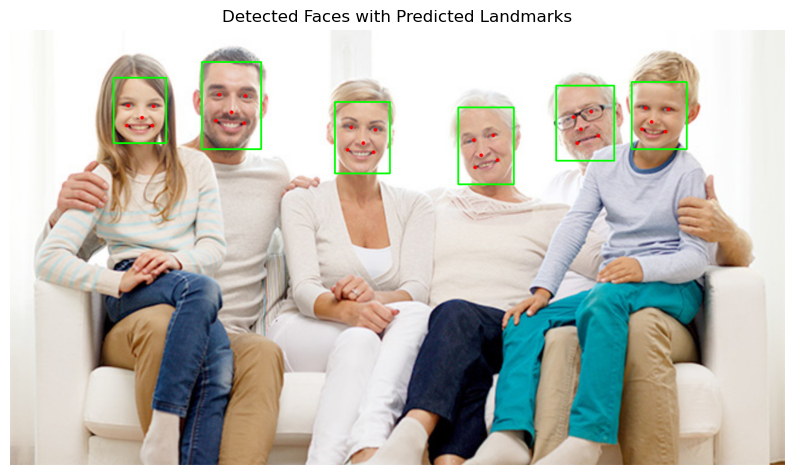

Successfully extracted and plotted landmarks for 6 faces.


In [ ]:
final_landmarks_on_original_image = []

for heatmap_tensor, original_bbox in predicted_heatmaps:
    # 1. Convert Heatmaps to Landmark Coordinates (64x64 space)
    # For each of the 5 landmarks, find the (x,y) coordinate of the maximum value in its heatmap channel.

    # Add batch dimension for heatmaps_to_landmarks function
    batched_heatmap_tensor = heatmap_tensor.unsqueeze(0)
    # Convert heatmaps to landmark coordinates (64x64 space) using the new function
    landmarks_64x64_tensor = heatmaps_to_landmarks(batched_heatmap_tensor)
    # Remove batch dimension and convert to list of tuples (x, y)
    heatmap_max_indices = [(int(pt[0].item()), int(pt[1].item())) for pt in landmarks_64x64_tensor.squeeze(0)]

    # The heatmaps are 64x64, but the input image to the model was 128x128.
    # So, scale the landmark coordinates by a factor of 2 (128/64).
    scaled_to_128x128_landmarks = [
        (int(round(x * (128 / heatmap_tensor.shape[2]))), int(round(y * (128 / heatmap_tensor.shape[1]))))
        for x, y in heatmap_max_indices
    ]

    # 2. Scale Landmark Coordinates to Original Bounding Box Space (reverse ResizeAndPad)
    bbox_x1, bbox_y1, bbox_x2, bbox_y2 = original_bbox
    original_cropped_width = bbox_x2 - bbox_x1
    original_cropped_height = bbox_y2 - bbox_y1

    # Recalculate scaling and padding based on the original cropped dimensions
    target_w, target_h = 128, 128
    scale = min(target_w / original_cropped_width, target_h / original_cropped_height)

    resized_w = int(original_cropped_width * scale)
    resized_h = int(original_cropped_height * scale)

    pad_w_left = (target_w - resized_w) // 2
    pad_h_top = (target_h - resized_h) // 2

    landmarks_in_original_bbox_space = []
    for lx_128, ly_128 in scaled_to_128x128_landmarks:
        # Remove padding offset
        lx_unpadded = lx_128 - pad_w_left
        ly_unpadded = ly_128 - pad_h_top

        # Reverse scaling to get coordinates relative to the original cropped image
        lx_original_cropped = lx_unpadded / scale
        ly_original_cropped = ly_unpadded / scale

        landmarks_in_original_bbox_space.append((lx_original_cropped, ly_original_cropped))

    # 3. Translate Landmark Coordinates to Original Image Space
    current_face_landmarks = []
    for lx_relative, ly_relative in landmarks_in_original_bbox_space:
        lx_absolute = int(round(lx_relative + bbox_x1))
        ly_absolute = int(round(ly_relative + bbox_y1))
        current_face_landmarks.append((lx_absolute, ly_absolute))

    final_landmarks_on_original_image.append(current_face_landmarks)

# 4. Overlay Landmarks on output_img_scrfd and Display
# Make a copy to avoid modifying the original output_img_scrfd (which already has bboxes)
output_img_with_landmarks = output_img_scrfd.copy()

for face_landmarks in final_landmarks_on_original_image:
    for (lx, ly) in face_landmarks:
        cv2.circle(output_img_with_landmarks, (lx, ly), 3, (0, 0, 255), -1) # Red circle, filled

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output_img_with_landmarks, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Detected Faces with Predicted Landmarks')
plt.show()

print(f"Successfully extracted and plotted landmarks for {len(final_landmarks_on_original_image)} faces.")


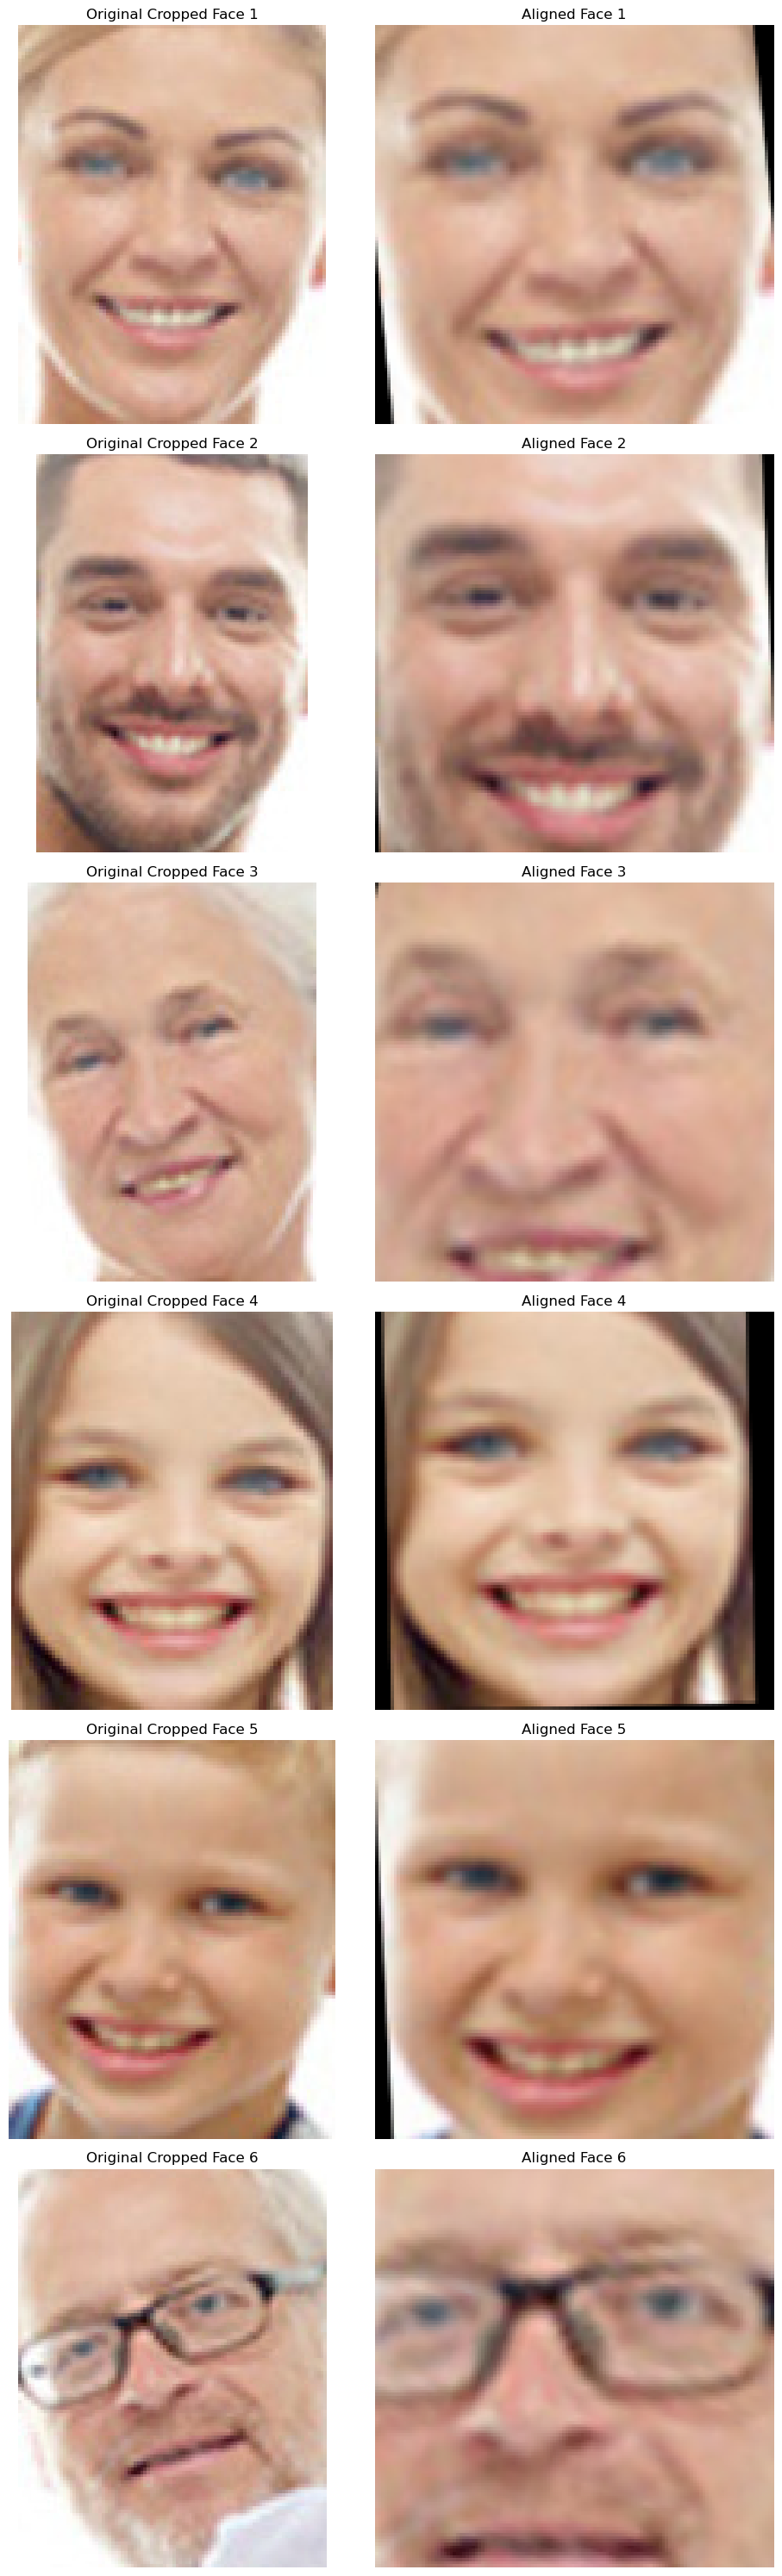

Successfully aligned and displayed 6 faces.


In [ ]:
import torchvision.transforms.v2 as T
from torchvision.tv_tensors import KeyPoints

face_align_transform = FaceAlign(
    target_size=(128, 128),
    target_left_eye=(0.28, 0.35),
    target_right_eye=(0.72, 0.35),
    target_mouth_y=0.75
)

aligned_faces_results = []

# Transform to convert PIL Image to tv_tensors.Image (Tensor)
pil_to_tensor_transform = T.Compose([
    T.PILToTensor(),
    T.ConvertImageDtype(torch.float)
])

# original_rgb_pil_image was created in cell a7841bb7
# faces was created in cell iDHsavHDykzJ
# final_landmarks_on_original_image was created in cell 128053cb

for i, face_info in enumerate(faces):
    # Get original bbox from the face detection result
    bbox = face_info['bbox'].astype(int)
    x1, y1, x2, y2 = bbox[0], bbox[1], bbox[2], bbox[3]

    # Ensure bbox coordinates are within image bounds before cropping
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(original_rgb_pil_image.width, x2)
    y2 = min(original_rgb_pil_image.height, y2)

    # Crop the original_rgb_pil_image to get the face region
    cropped_pil_image = original_rgb_pil_image.crop((x1, y1, x2, y2))
    cropped_width, cropped_height = cropped_pil_image.size

    # Get predicted landmarks for this face (these are in original image absolute coordinates)
    predicted_abs_landmarks = final_landmarks_on_original_image[i]

    # Convert absolute predicted landmarks to relative landmarks for the cropped image
    relative_predicted_landmarks = []
    for lx_abs, ly_abs in predicted_abs_landmarks:
        lx_relative = lx_abs - x1
        ly_relative = ly_abs - y1
        relative_predicted_landmarks.append((lx_relative, ly_relative))

    # Create KeyPoints object for FaceAlign. canvas_size refers to the size of the image
    # that these keypoints are relative to, which is the cropped_pil_image.
    keypoints_for_align = KeyPoints(torch.tensor(relative_predicted_landmarks, dtype=torch.float),
                                     canvas_size=(cropped_height, cropped_width))

    # Convert cropped_pil_image to tv_tensors.Image before passing to FaceAlign
    cropped_tv_image = pil_to_tensor_transform(cropped_pil_image)

    # Apply FaceAlign transform
    # The FaceAlign transform expects a dictionary with 'image' (tv_tensors.Image) and 'keypoints'
    aligned_data = face_align_transform({'image': cropped_tv_image, 'keypoints': keypoints_for_align})
    aligned_pil_image = aligned_data['image']

    aligned_faces_results.append((cropped_pil_image, aligned_pil_image))

# Display the results
# Determine the number of rows for subplots (one row per face, showing original and aligned)
num_faces_to_display = len(aligned_faces_results)

plt.figure(figsize=(10, 5 * num_faces_to_display)) # Adjust figure size dynamically

for i, (original_cropped_face, aligned_face) in enumerate(aligned_faces_results):
    # Display original cropped face
    plt.subplot(num_faces_to_display, 2, 2 * i + 1)
    plt.imshow(original_cropped_face)
    plt.title(f'Original Cropped Face {i+1}')
    plt.axis('off')

    # Display aligned face
    plt.subplot(num_faces_to_display, 2, 2 * i + 2)
    # Move the tensor to CPU, permute dimensions from CHW to HWC, and convert to numpy
    plt.imshow(aligned_face.cpu().permute(1, 2, 0).numpy())
    plt.title(f'Aligned Face {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Successfully aligned and displayed {len(aligned_faces_results)} faces.")

In [ ]:

#______________________ЗАГРУЗКА МОДЕЛИ ДЛЯ ДЕТЕКЦИИ ЛИЦ___________________________
from insightface.app import FaceAnalysis
import cv2
import matplotlib.pyplot as plt

detection_model = FaceAnalysis(allowed_modules=['detection'], det_name='scrfd_10g_bnkps')
detection_model.prepare(ctx_id=0, det_size=(640, 640)) # ctx_id=0 для GPU

#______________________ЗАГРУЗКА МОДЕЛИ ДЛЯ РАСПОЗНАВАНИЯ ЛЭНДМАРКОВ___________________________
%run PROJECT/FaceAlignment/hourglass_network.py
import torch
from torch import device

device = "cuda" if torch.cuda.is_available() else "cpu"

# Параметры модели
num_stacks = 4 # Количество HourglassModule
depth = 5 # Глубина HourglassModule
in_channels = 256
out_channels = 256
num_landmarks = 5

landmarks_model = StackedHourglassNetwork(num_stacks, depth, in_channels, out_channels, num_landmarks).to(device)
landmarks_model.load_state_dict(torch.load(f'{project_path}/best_landmark_model.pth'))

#______________________ЗАГРУЗКА МОДЕЛИ ДЛЯ РАСПОЗНАВАНИЯ___________________________
%run PROJECT/FaceAlignment/FaceRecognitionCEModel.py
FaceRecognition_model = FaceRecognitionModel(embedding_dim=512, num_classes=1944)
FaceRecognition_model.load_state_dict(torch.load(f'{project_path}/FR_linear.pth'))
FaceRecognition_model.to(device)
FaceRecognition_model.eval()

In [ ]:
from insightface.app import FaceAnalysis
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torchvision.transforms.v2 as T
from torchvision.tv_tensors import KeyPoints
from PIL import Image
import numpy as np
import torch.nn.functional as F # Import F for normalization
import torch
from torch import device
import os
import sys

device = "cuda" if torch.cuda.is_available() else "cpu"

%run PROJECT/FaceAlignment/hourglass_network.py
%run PROJECT/FaceAlignment/FaceRecognitionCEModel.py
%run PROJECT/FaceAlignment/FaceRecognitionArcFaceModel.py

class SuppressOutput:
    """Context manager to suppress stdout and stderr."""
    def __enter__(self):
        self._original_stdout = sys.stdout
        self._original_stderr = sys.stderr
        self._devnull = open(os.devnull, 'w')
        sys.stdout = self._devnull
        sys.stderr = self._devnull

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout = self._original_stdout
        sys.stderr = self._original_stderr
        self._devnull.close()

class FaceRecognitionPipeline:
    def __init__(self):
        #______________________ЗАГРУЗКА МОДЕЛИ ДЛЯ ДЕТЕКЦИИ ЛИЦ___________________________
        with SuppressOutput():
            detection_model = FaceAnalysis(allowed_modules=['detection'], det_name='scrfd_10g_bnkps')
            detection_model.prepare(ctx_id=0, det_size=(640, 640)) # ctx_id=0 для GPU
        self.detection_model = detection_model


        #__________________ЗАГРУЗКА МОДЕЛИ ДЛЯ РАСПОЗНАВАНИЯ ЛЭНДМАРКОВ____________________
        num_stacks = 4
        depth = 5
        in_channels = 256
        out_channels = 256
        num_landmarks = 5

        landmarks_model = StackedHourglassNetwork(num_stacks, depth, in_channels, out_channels, num_landmarks).to(device)
        landmarks_model.load_state_dict(torch.load(f'{project_path}/best_landmark_model.pth'))
        self.landmarks_model = landmarks_model
        self.landmarks_model.eval()

        #______________________ЗАГРУЗКА МОДЕЛИ ДЛЯ РАСПОЗНАВАНИЯ___________________________
        # face_recognition_model.load_state_dict(torch.load(f'{project_path}/FR_linear.pth'))
        # face_recognition_model = FaceRecognitionModel(embedding_dim=512, num_classes=1944)
        face_recognition_model = FaceRecognitionArcFaceModel(embedding_dim=512, num_classes=1944, s=64.0, m=0.4)
        face_recognition_model.load_state_dict(torch.load(f'{project_path}/FR_ArcFace.pth'))
        face_recognition_model.to(device)
        self.face_recognition_model = face_recognition_model
        self.face_recognition_model.eval()

        # ____________________ИНИЦИАЛИЗАЦИЯ ОСНОВНЫХ ТРАНСФОРМАЦИЙ_________________________`
        self.resize_and_pad_transform = ResizeAndPad(output_size=(128, 128))

        self.pil_to_tensor_transform = T.Compose([
            T.PILToTensor(),
            T.ConvertImageDtype(torch.float)
        ])

        self.normalize = T.Compose([
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        self.face_align_transform = FaceAlign(
            target_size=(128, 128),
            target_left_eye=(0.28, 0.35),
            target_right_eye=(0.72, 0.35),
            target_mouth_y=0.75
        )

        #_____________________________________________________________________________________


    def _process_single_image(self, item):
        # 1. Load the image
        image_path = item['image_path']
        input_img_bgr = cv2.imread(image_path)
        if input_img_bgr is None:
            print(f"ОШИБКА: Не получилось загрузить изображение из {image_path}")
            return [] # Return empty list if image loading fails

        # Convert BGR to RGB PIL image for torchvision transforms
        original_rgb_pil_image = Image.fromarray(cv2.cvtColor(input_img_bgr, cv2.COLOR_BGR2RGB))

        # 2. Perform face detection
        faces = self.detection_model.get(input_img_bgr)
        if len(faces) == 0:
            print(f"На изображении {image_path.split('/')[-1]} не было найдено лиц.")
            return []

        all_face_data = []

        for face in faces:
            # Extract the bounding box coordinates (x1, y1, x2, y2)
            bbox = face.bbox.astype(int)
            x1, y1, x2, y2 = bbox[0], bbox[1], bbox[2], bbox[3]

            # Ensure bbox coordinates are within image bounds before cropping
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(original_rgb_pil_image.width, x2)
            y2 = min(original_rgb_pil_image.height, y2)

            # Crop the original_rgb_pil_image to get the face region for landmark prediction
            cropped_pil_image_for_lm = original_rgb_pil_image.crop((x1, y1, x2, y2))
            cropped_width_lm, cropped_height_lm = cropped_pil_image_for_lm.size

            # Convert cropped PIL Image to tv_tensors.Image (Tensor)
            cropped_tv_image_for_lm = self.pil_to_tensor_transform(cropped_pil_image_for_lm)

            # Create a dummy KeyPoints object for ResizeAndPad for landmark model input
            dummy_keypoints_obj_lm = KeyPoints(torch.empty(0, 2), canvas_size=(cropped_height_lm, cropped_width_lm))

            # Apply ResizeAndPad and Normalize for landmark prediction input
            resized_padded_data_lm = self.resize_and_pad_transform({'image': cropped_tv_image_for_lm, 'keypoints': dummy_keypoints_obj_lm})
            preprocessed_tensor_lm = self.normalize(resized_padded_data_lm['image'])

            # Predict heatmaps using landmarks_model
            input_tensor_lm = preprocessed_tensor_lm.unsqueeze(0).to(device)
            output_heatmaps_list = self.landmarks_model(input_tensor_lm)
            heatmap = output_heatmaps_list[-1].squeeze(0).cpu()

            # Convert Heatmaps to Landmark Coordinates (64x64 space)
            batched_heatmap_tensor = heatmap.unsqueeze(0)
            landmarks_64x64_tensor = heatmaps_to_landmarks(batched_heatmap_tensor)
            heatmap_max_indices = [(pt[0].item(), pt[1].item()) for pt in landmarks_64x64_tensor.squeeze(0)]

            # Scale landmarks to 128x128 (model input size)
            scaled_to_128x128_landmarks = [
                (x * (128 / heatmap.shape[2]), y * (128 / heatmap.shape[1]))
                for x, y in heatmap_max_indices
            ]

            # Reverse ResizeAndPad to get landmarks in original cropped bbox space
            target_w, target_h = 128, 128
            scale_factor = min(target_w / cropped_width_lm, target_h / cropped_height_lm)

            resized_w_orig = cropped_width_lm * scale_factor
            resized_h_orig = cropped_height_lm * scale_factor

            pad_w_left = (target_w - resized_w_orig) / 2
            pad_h_top = (target_h - resized_h_orig) / 2

            landmarks_in_original_bbox_space = []
            for lx_128, ly_128 in scaled_to_128x128_landmarks:
                lx_unpadded = lx_128 - pad_w_left
                ly_unpadded = ly_128 - pad_h_top

                lx_original_cropped = lx_unpadded / scale_factor
                ly_original_cropped = ly_unpadded / scale_factor

                landmarks_in_original_bbox_space.append((lx_original_cropped, ly_original_cropped))

            # Create KeyPoints object for FaceAlign with relative landmarks to the cropped image
            keypoints_for_align = KeyPoints(torch.tensor(landmarks_in_original_bbox_space, dtype=torch.float),
                                            canvas_size=(cropped_height_lm, cropped_width_lm))

            # Crop the original_rgb_pil_image again for FaceAlign (ensure it's the same crop as used for landmarks)
            cropped_pil_image_for_align = original_rgb_pil_image.crop((x1, y1, x2, y2))
            cropped_tv_image_for_align = self.pil_to_tensor_transform(cropped_pil_image_for_align)

            # Apply FaceAlign transform
            aligned_data = self.face_align_transform({'image': cropped_tv_image_for_align, 'keypoints': keypoints_for_align})
            aligned_face_tensor = aligned_data['image']

            # Apply normalization for the Face Recognition model
            normalized_aligned_face_tensor = self.normalize(aligned_face_tensor)

            # Get embeddings from the backbone
            input_batch_fr = normalized_aligned_face_tensor.unsqueeze(0).to(device)
            raw_embeddings = self.face_recognition_model.backbone(input_batch_fr)

            # Normalize the embeddings
            normalized_embeddings = F.normalize(raw_embeddings, p=2, dim=1)

            # Append dictionary with embedding, bbox, and image_index
            all_face_data.append({
                'embedding': normalized_embeddings.cpu(),
                'bbox': (x1, y1, x2, y2),
                'image_index': item['index']
            })

        print(f"Успешно извлечено {len(all_face_data)} данных о лицах из {image_path.split('/')[-1]}.")
        return all_face_data

    def __call__(self, input_images_paths):
        # Prepare a list of dictionaries, each containing image_path and its index
        images_to_process = []
        for i, path in enumerate(input_images_paths):
            images_to_process.append({'image_path': path, 'index': i})

        # Disable gradient calculations for inference
        with torch.no_grad():
            all_faces_data = []
            for item in images_to_process:
                faces_data_from_single_image = self._process_single_image(item)
                all_faces_data.extend(faces_data_from_single_image)

            print(f"Всего обработано лиц: {len(all_faces_data)}")
            return all_faces_data

In [ ]:
img_2 = 'PROJECT/FaceAlignment/test2.jpg'
img_3 = 'PROJECT/FaceAlignment/test3.jpg'
img_4 = 'PROJECT/FaceAlignment/chel.jpg'
family2_1 = 'PROJECT/FaceAlignment/family2.1.jpg'
family2_2 = 'PROJECT/FaceAlignment/family2.2.jpg'

In [ ]:
pipeline = FaceRecognitionPipeline()
input_image_paths = [family2_1, family2_2]
all_faces_data = pipeline(input_image_paths)

Успешно извлечено 8 данных о лицах из family2.1.jpg.
Успешно извлечено 8 данных о лицах из family2.2.jpg.
Всего обработано лиц: 16


In [ ]:
import cv2
import matplotlib.pyplot as plt
import torch
import itertools

def compare_and_visualize_faces(all_faces_data, input_image_paths, similarity_threshold=0.6):
    """
    Orchestrates the comparison and visualization of faces.

    Args:
        all_faces_data (list): A list of dictionaries, where each dictionary contains
                                'embedding', 'bbox', and 'image_index' for a detected face.
        input_image_paths (list): A list of paths to the original input images.
        similarity_threshold (float): The minimum cosine similarity required to consider two faces the same.
    """
    # 1. Load all original images into a dictionary for easy access
    # Keys will be image indices, values will be BGR NumPy arrays
    original_images = {}
    for i, img_path in enumerate(input_image_paths):
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not load image from {img_path}. Skipping.")
            continue
        original_images[i] = img

    print(f"Loaded {len(original_images)} original images.")

    # Store pairs of faces that have high similarity
    matched_pairs = []

    # Iterate through unique pairs of faces in all_faces_data
    # Using itertools.combinations to get all unique pairs
    for face1, face2 in itertools.combinations(all_faces_data, 2):
        embedding1 = face1['embedding']
        embedding2 = face2['embedding']

        # Calculate cosine similarity
        # F.cosine_similarity expects tensors of shape (N, D)
        similarity = torch.nn.functional.cosine_similarity(embedding1, embedding2).item()

        if similarity >= similarity_threshold:
            matched_pairs.append({
                'face1': face1,
                'face2': face2,
                'similarity': similarity
            })

    print(f"Found {len(matched_pairs)} matched face pairs above the similarity threshold.")

    # Visualize matched pairs
    if matched_pairs:
        num_plots = len(matched_pairs)
        fig, axes = plt.subplots(num_plots, 2, figsize=(10, 5 * num_plots))

        # Ensure axes is always a 2D array for consistent indexing
        if num_plots == 1:
            axes = [axes] # Make it a list of lists if only one row

        for i, match in enumerate(matched_pairs):
            face1_data = match['face1']
            face2_data = match['face2']
            similarity = match['similarity']

            img_idx1 = face1_data['image_index']
            img_idx2 = face2_data['image_index']
            bbox1 = face1_data['bbox']
            bbox2 = face2_data['bbox']

            # Load original images (or get from cache)
            img1_original = original_images.get(img_idx1)
            img2_original = original_images.get(img_idx2)

            if img1_original is None or img2_original is None:
                print(f"Skipping visualization for a pair due to missing image(s).")
                continue

            # Create copies to draw bounding boxes
            img1_display = img1_original.copy()
            img2_display = img2_original.copy()

            # Draw green bounding boxes
            cv2.rectangle(img1_display, (bbox1[0], bbox1[1]), (bbox1[2], bbox1[3]), (0, 255, 0), 2)
            cv2.rectangle(img2_display, (bbox2[0], bbox2[1]), (bbox2[2], bbox2[3]), (0, 255, 0), 2)

            # Display the images side-by-side
            ax1 = axes[i][0]
            ax2 = axes[i][1]

            ax1.imshow(cv2.cvtColor(img1_display, cv2.COLOR_BGR2RGB))
            ax1.set_title(f'Image {img_idx1}\nSimilarity: {similarity:.2f}')
            ax1.axis('off')

            ax2.imshow(cv2.cvtColor(img2_display, cv2.COLOR_BGR2RGB))
            ax2.set_title(f'Image {img_idx2}')
            ax2.axis('off')

        plt.tight_layout()
        plt.show()

Loaded 2 original images.
Found 8 matched face pairs above the similarity threshold.


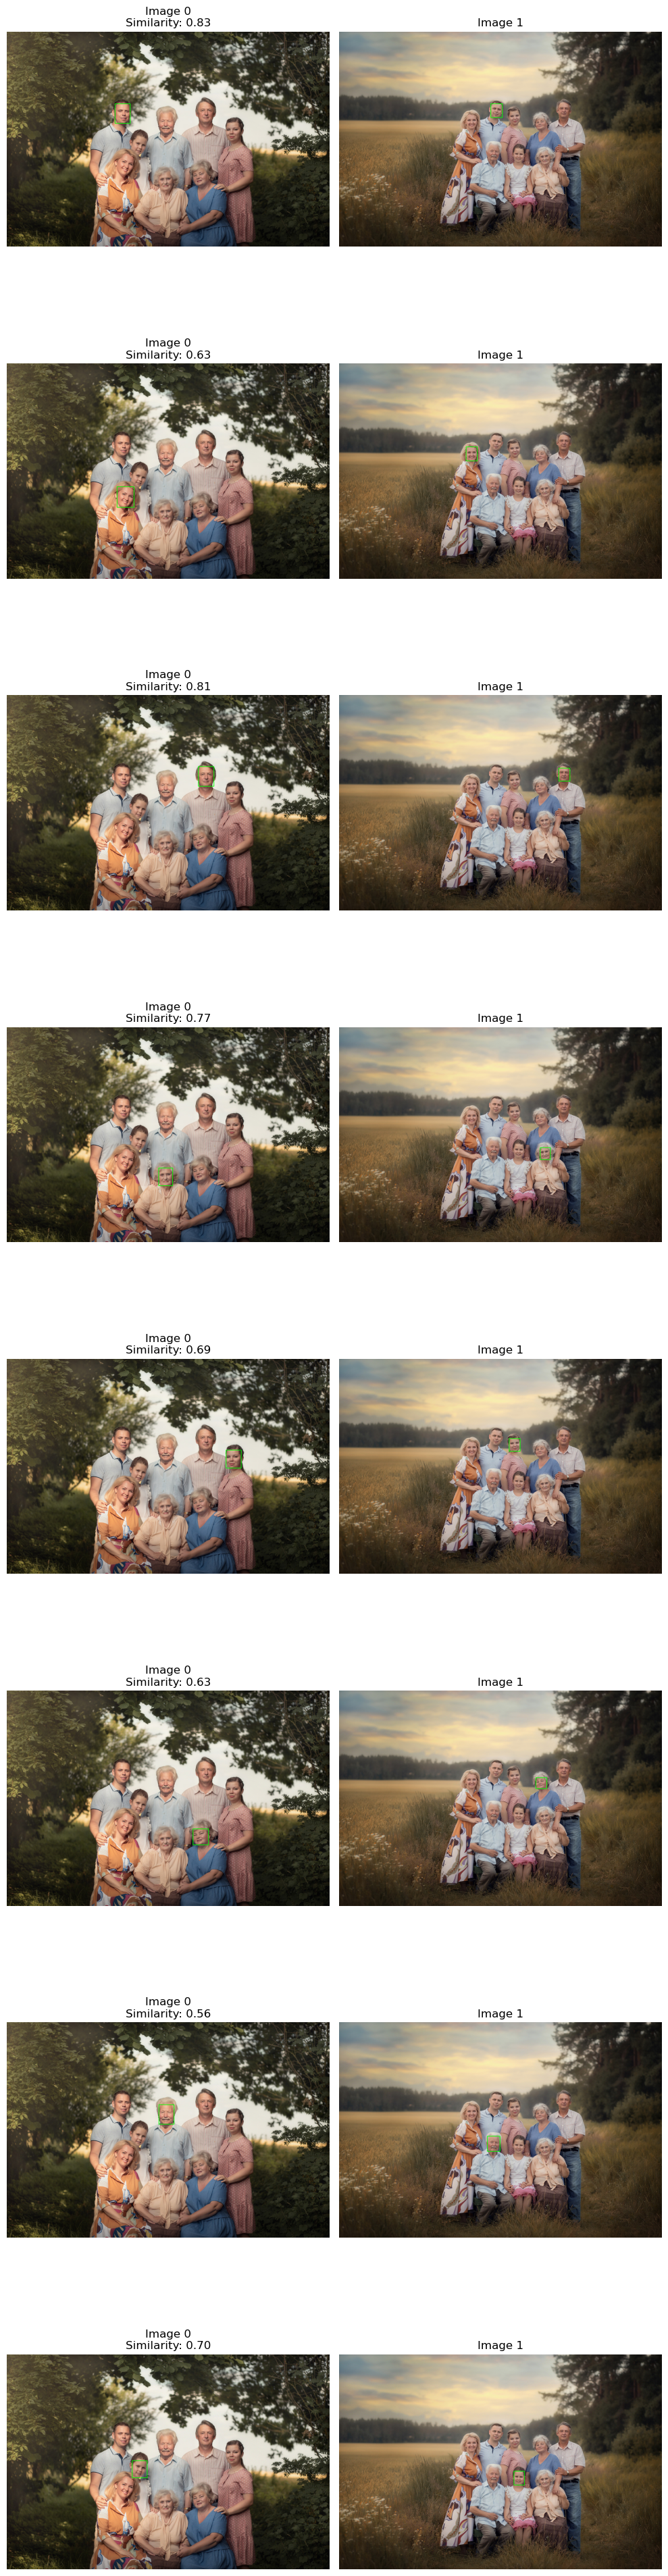

In [ ]:
compare_and_visualize_faces(all_faces_data, input_image_paths, similarity_threshold=0.55)